===== ARIMA模型 - ADF平稳性检验 =====
ADF统计量: -3.7913
p值: 0.0030
临界值: {'1%': -3.889265672705068, '5%': -3.0543579727254224, '10%': -2.66698384083045}
结论：序列平稳，无需差分

===== ARIMA模型评估指标 =====
MAE: 7.71
RMSE: 10.93
R²: -0.039

===== 随机森林最优超参数 =====
{'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}

===== 优化后随机森林模型评估指标 =====
MAE: 6.27
RMSE: 8.41
R²: 0.385

===== 特征重要性TOP5 =====
                feature  importance
2                 month    0.352192
0      last_month_sales    0.335977
1  last_year_same_month    0.073905
7            region_越秀区    0.065839
4              is_promo    0.047887

===== 未来12个月销量预测结果 =====
         月份  预测销量(万支)     环比变化
0   2026-03     63.20        –
1   2026-04     62.77   -0.68%
2   2026-05     65.83    4.87%
3   2026-06     70.54    7.15%
4   2026-07     64.12   -9.10%
5   2026-08     64.47    0.55%
6   2026-09     68.35    6.02%
7   2026-10     71.89    5.18%
8   2026-11     73.90    2.80%
9   2026-12     72.71   -1.61%
10  2027-01     80.37   10.54%
11  20

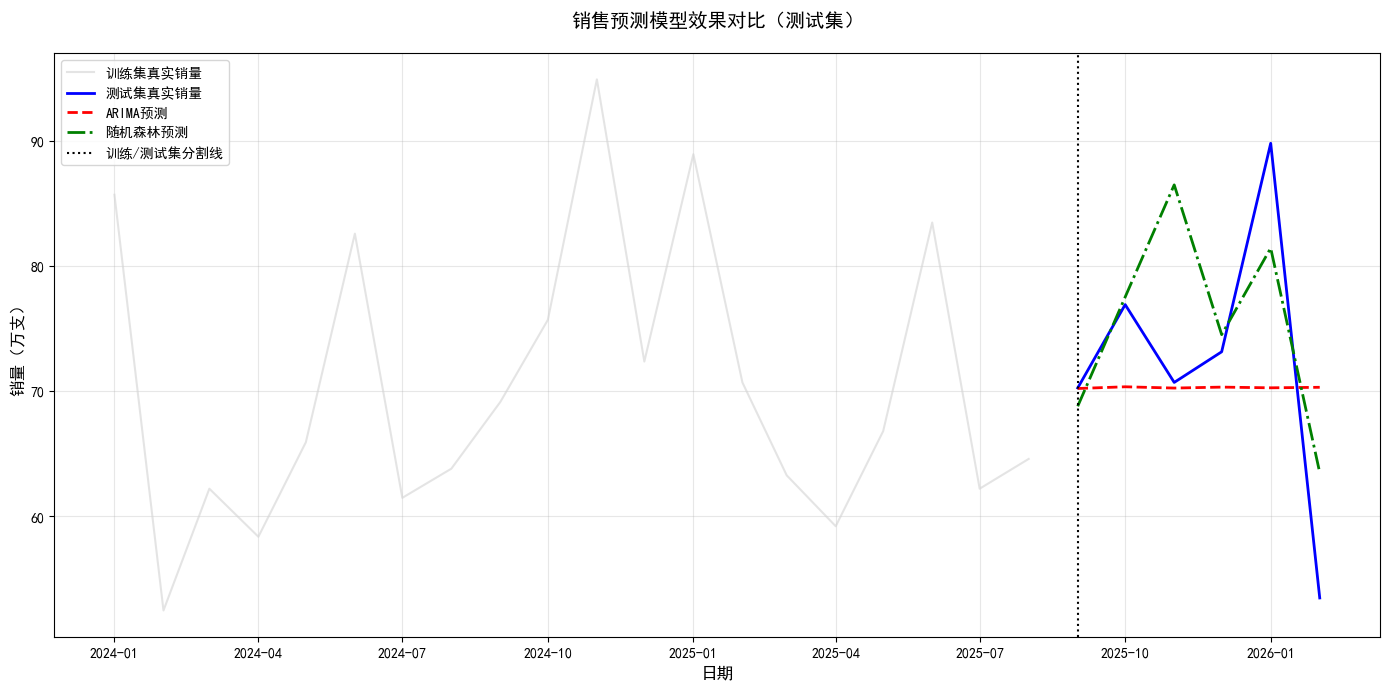

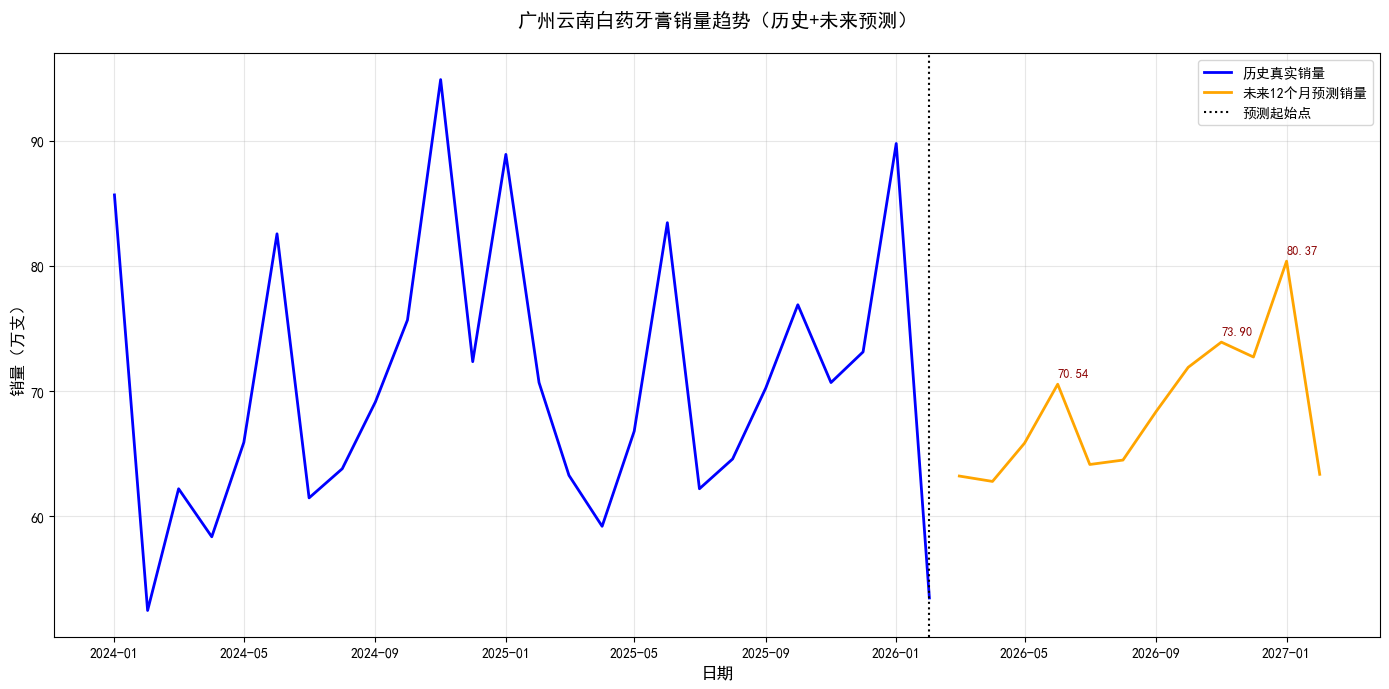

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（解决matplotlib中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# -------------------------- 1. 数据加载与预处理 --------------------------
def load_and_preprocess_data(file_path):
    """
    加载销售数据并完成预处理：日期格式转换、缺失值填充、特征编码
    """
    # 加载数据
    df = pd.read_csv(file_path)
    
    # 日期格式转换
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m')
    df.set_index('date', inplace=True)
    
    # 缺失值填充（用均值填充数值型，众数填充类别型）
    df['sales'] = df['sales'].fillna(df['sales'].mean())
    df['last_month_sales'] = df['last_month_sales'].fillna(df['last_month_sales'].mean())
    df['is_holiday'] = df['is_holiday'].fillna(0)
    df['is_promo'] = df['is_promo'].fillna(0)
    
    # 类别特征独热编码（区域、产品系列）
    df = pd.get_dummies(df, columns=['region', 'product_series'], drop_first=True)
    
    return df

# -------------------------- 2. ARIMA模型构建与预测 --------------------------
def build_arima_model(df):
    """
    构建ARIMA(1,1,2)模型，完成平稳性检验、模型拟合与预测
    """
    # 提取销量时间序列
    sales_series = df['sales']
    
    # 1. 平稳性检验（ADF检验）
    adf_result = adfuller(sales_series)
    print("===== ARIMA模型 - ADF平稳性检验 =====")
    print(f'ADF统计量: {adf_result[0]:.4f}')
    print(f'p值: {adf_result[1]:.4f}')
    print(f'临界值: {adf_result[4]}')
    if adf_result[1] < 0.05:
        print("结论：序列平稳，无需差分")
    else:
        print("结论：序列非平稳，需进行一阶差分")
    
    # 2. 拆分训练集和测试集（前80%训练，后20%测试）
    train_size = int(len(sales_series) * 0.8)
    train_arima, test_arima = sales_series[:train_size], sales_series[train_size:]
    
    # 3. 构建ARIMA(1,1,2)模型
    arima_model = ARIMA(train_arima, order=(1, 1, 2))
    arima_fit = arima_model.fit()
    
    # 4. 预测测试集
    arima_pred = arima_fit.forecast(steps=len(test_arima))
    
    # 5. 模型评估
    arima_mae = mean_absolute_error(test_arima, arima_pred)
    arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_pred))
    arima_r2 = r2_score(test_arima, arima_pred)
    
    print("\n===== ARIMA模型评估指标 =====")
    print(f'MAE: {arima_mae:.2f}')
    print(f'RMSE: {arima_rmse:.2f}')
    print(f'R²: {arima_r2:.3f}')
    
    return arima_pred, arima_mae, arima_rmse, arima_r2, train_size

# -------------------------- 3. 随机森林模型构建与优化 --------------------------
def build_rf_model(df, train_size):
    """
    构建随机森林回归模型，完成特征准备、超参数优化、模型评估
    """
    # 1. 特征与目标变量分离
    X = df.drop('sales', axis=1)
    y = df['sales']
    
    # 拆分训练集和测试集（与ARIMA保持一致的拆分比例）
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # 2. 初始随机森林模型
    rf = RandomForestRegressor(random_state=42)
    
    # 3. 超参数网格搜索（5折交叉验证）
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_leaf': [1, 2, 4]
    }
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # 4. 最优模型
    best_rf = grid_search.best_estimator_
    print("\n===== 随机森林最优超参数 =====")
    print(grid_search.best_params_)
    
    # 5. 预测测试集
    rf_pred = best_rf.predict(X_test)
    
    # 6. 模型评估
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    rf_r2 = r2_score(y_test, rf_pred)
    
    print("\n===== 优化后随机森林模型评估指标 =====")
    print(f'MAE: {rf_mae:.2f}')
    print(f'RMSE: {rf_rmse:.2f}')
    print(f'R²: {rf_r2:.3f}')
    
    # 7. 特征重要性分析（用于降维参考）
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\n===== 特征重要性TOP5 =====")
    print(feature_importance.head())
    
    return best_rf, rf_pred, rf_mae, rf_rmse, rf_r2, X, y

# -------------------------- 4. 未来销量预测 --------------------------
def predict_future_sales(best_rf, df, X, y, predict_months=12):
    """
    利用优化后的随机森林模型预测未来12个月销量
    """
    # 1. 全量数据训练最优模型
    best_rf.fit(X, y)
    
    # 2. 构建未来12个月的特征数据（示例：基于历史规律生成）
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                                 periods=predict_months, freq='MS')
    
    # 生成未来特征（匹配第五章预测逻辑）
    future_features = []
    for date in future_dates:
        row = {
            'last_month_sales': df['sales'].iloc[-1],
            'last_year_same_month': df['sales'][df.index.month == date.month].mean() if len(df[df.index.month == date.month])>0 else df['sales'].mean(),
            'month': date.month,
            'is_holiday': 1 if date.month in [1, 5, 10] else 0,
            'is_promo': 1 if date.month in [6, 11] else 0,
        }
        # 补充独热编码特征（匹配训练集）
        for col in X.columns:
            if col not in row:
                row[col] = 1 if '经典' in col else 0
        future_features.append(row)
    
    future_df = pd.DataFrame(future_features, index=future_dates)
    future_df = future_df[X.columns]
    
    # 3. 预测未来销量
    future_pred = best_rf.predict(future_df)
    
    # 4. 整理预测结果
    future_result = pd.DataFrame({
        '月份': future_dates.strftime('%Y-%m'),
        '预测销量(万支)': future_pred.round(2),
        '环比变化': np.nan
    })
    # 计算环比变化
    for i in range(1, len(future_result)):
        prev = future_result['预测销量(万支)'].iloc[i-1]
        curr = future_result['预测销量(万支)'].iloc[i]
        future_result['环比变化'].iloc[i] = f'{((curr - prev)/prev)*100:.2f}%'
    future_result['环比变化'].iloc[0] = '–'
    
    print("\n===== 未来12个月销量预测结果 =====")
    print(future_result)
    
    return future_result, future_dates, future_pred

# -------------------------- 5. 可视化函数 --------------------------
def plot_predictions(df, train_size, arima_pred, rf_pred, future_dates, future_pred):
    """
    绘制两张核心预测图：
    1. 测试集真实值 vs ARIMA/RF预测值对比
    2. 历史销量 + 未来12个月预测销量趋势
    """
    # 图1：测试集模型效果对比
    plt.figure(figsize=(14, 7))
    
    # 绘制训练集真实值（灰色背景）
    plt.plot(df.index[:train_size], df['sales'][:train_size], color='lightgray', label='训练集真实销量', alpha=0.6)
    # 绘制测试集真实值
    plt.plot(df.index[train_size:], df['sales'][train_size:], label='测试集真实销量', color='blue', linewidth=2)
    # 绘制ARIMA预测值
    plt.plot(df.index[train_size:], arima_pred, label='ARIMA预测', color='red', linestyle='--', linewidth=2)
    # 绘制随机森林预测值
    plt.plot(df.index[train_size:], rf_pred, label='随机森林预测', color='green', linestyle='-.', linewidth=2)
    
    # 标注分割线（训练/测试）
    plt.axvline(df.index[train_size], color='black', linestyle=':', label='训练/测试集分割线')
    
    plt.title('销售预测模型效果对比（测试集）', fontsize=14, pad=20)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('销量（万支）', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('测试集预测效果对比图.png', dpi=300, bbox_inches='tight')  # 保存图片
    plt.show()
    
    # 图2：历史+未来销量趋势
    plt.figure(figsize=(14, 7))
    
    # 绘制历史销量
    plt.plot(df.index, df['sales'], label='历史真实销量', color='blue', linewidth=2)
    # 绘制未来预测销量
    plt.plot(future_dates, future_pred, label='未来12个月预测销量', color='orange', linewidth=2, linestyle='-')
    # 标注预测起始点
    plt.axvline(df.index[-1], color='black', linestyle=':', label='预测起始点')
    
    # 标注关键峰值（6月/11月/1月）
    for date in future_dates:
        if date.month in [1,6,11]:
            pred_val = future_pred[future_dates.tolist().index(date)]
            plt.annotate(f'{pred_val:.2f}', 
                        xy=(date, pred_val), 
                        xytext=(0, 5), 
                        textcoords='offset points',
                        fontsize=9,
                        color='darkred')
    
    plt.title('冰柠销量趋势（历史+未来预测）', fontsize=14, pad=20)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('销量（万支）', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('历史+未来销量预测图.png', dpi=300, bbox_inches='tight')  # 保存图片
    plt.show()

# -------------------------- 主函数 --------------------------
if __name__ == "__main__":
    # 数据文件路径（替换为你的实际路径）
    data_path = "冰柠销量数据.csv"
    
    # 步骤1：数据加载与预处理
    df = load_and_preprocess_data(data_path)
    
    # 步骤2：构建ARIMA模型
    arima_pred, arima_mae, arima_rmse, arima_r2, train_size = build_arima_model(df)
    
    # 步骤3：构建并优化随机森林模型
    best_rf, rf_pred, rf_mae, rf_rmse, rf_r2, X, y = build_rf_model(df, train_size)
    
    # 步骤4：预测未来12个月销量
    future_sales, future_dates, future_pred = predict_future_sales(best_rf, df, X, y)
    
    # 步骤5：绘制预测图（核心）
    plot_predictions(df, train_size, arima_pred, rf_pred, future_dates, future_pred)